This notebook builds a face-recognition pipeline on LFW and measures how a hat-based occlusion changes verification performance.

In [1]:
!pip install kaggle

In [4]:
!pip install -U insightface onnxruntime-gpu

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 439.5/439.5 kB 15.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 271.3/271.3 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 52.1 MB/s eta 0:00:00
  Created wheel for insightface: filename=insightface-0.7.3-cp312-cp312-linux_x86_64.whl size=1071489 sha256=e59a3ac0ee44a3f09f6fba6648b6153ab90d00b8c425fffd0e2341582d92292c
  Stored in directory: /root/.cache/pip/wheels/73/3c/e2/6d4815e8a8b33a2006554d65ce0d1f973e768f4c7a222fa675
Successfully built insightface


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("atulanandjha/lfwpeople")

print("Path to dataset files:", path)

100%|██████████| 232M/232M [00:02<00:00, 81.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/atulanandjha/lfwpeople/versions/3


In [5]:
import os
import cv2
import numpy as np
from tqdm import tqdm
from insightface.app import FaceAnalysis

app = FaceAnalysis(name='buffalo_l', providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
app.prepare(ctx_id=0, det_size=(640, 640))

download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:03<00:00, 80092.88KB/s]


Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with o

The next cells extract and normalize embeddings from LFW identities, then run quick similarity checks.

In [8]:
import os
import cv2
import numpy as np
from tqdm import tqdm

def extract_face_data(base_path):
    embeddings = []
    labels = []

    # LFW directory search (handles nested /lfw/lfw/ structure)
    search_dirs = [
        os.path.join(base_path, "lfw-funneled/lfw_funneled"),
        os.path.join(base_path, "lfw"),
        base_path
    ]

    data_dir = None
    for d in search_dirs:
        if os.path.exists(d) and any(os.path.isdir(os.path.join(d, item)) for item in os.listdir(d)):
            data_dir = d
            break

    if not data_dir:
        print("Error: Could not find identity folders. Check path structure.")
        return np.array([]), np.array([])

    person_folders = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]

    for person_name in tqdm(person_folders, desc="Processing"):
        person_path = os.path.join(data_dir, person_name)
        for img_name in os.listdir(person_path):
            img = cv2.imread(os.path.join(person_path, img_name))
            if img is None: continue

            # Strategy 1: Standard detection
            faces = app.get(img)

            # Strategy 2: If detection fails, add padding (LFW faces are often too close to edges)
            if len(faces) == 0:
                padded_img = cv2.copyMakeBorder(img, 50, 50, 50, 50, cv2.BORDER_CONSTANT, value=[0,0,0])
                faces = app.get(padded_img)

            if len(faces) > 0:
                embeddings.append(faces[0].normed_embedding)
                labels.append(person_name)

    return np.array(embeddings), np.array(labels)

In [11]:
import tarfile

# Define the zip path and extraction target
zip_path = os.path.join(path, "lfw-funneled.tgz")
extract_path = os.path.join(path, "extracted_lfw")

if not os.path.exists(extract_path):
    os.makedirs(extract_path)
    print("Extracting dataset... this may take a minute.")
    with tarfile.open(zip_path, "r:gz") as tar:
        tar.extractall(path=extract_path)
    print("Extraction complete.")
else:
    print("Dataset already extracted.")

Extracting dataset... this may take a minute.


/tmp/ipykernel_1384/1394216835.py:11: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_path)


Extraction complete.


In [12]:
# The actual images are usually deep inside: extracted_lfw/lfw_funneled/
lfw_final_path = os.path.join(extract_path, "lfw_funneled")

# Run the extraction function from the previous step
X, y = extract_face_data(lfw_final_path)

if len(X) > 0:
    print(f"\nSuccess! Extracted {len(X)} embeddings.")
    print(f"Total Identities: {len(np.unique(y))}")
else:
    # If it still fails, let's see exactly what is in that folder
    print("\nFolders still not found. Directory check:")
    !ls {lfw_final_path} | head -n 10

Processing: 100%|██████████| 5749/5749 [08:29<00:00, 11.29it/s]


Success! Extracted 13233 embeddings.
Total Identities: 5749


In [13]:
if len(X) > 0:
    print("Data Shape:", X.shape)

    print("Sample identities:", np.unique(y)[:5])

Data Shape: (13233, 512)
Sample identities: ['AJ_Cook' 'AJ_Lamas' 'Aaron_Eckhart' 'Aaron_Guiel' 'Aaron_Patterson']


In [14]:
from sklearn.metrics.pairwise import cosine_similarity

def test_recognition(idx1, idx2):
    # Calculate similarity
    emb1 = X[idx1].reshape(1, -1)
    emb2 = X[idx2].reshape(1, -1)
    similarity = cosine_similarity(emb1, emb2)[0][0]

    name1, name2 = y[idx1], y[idx2]
    is_match = name1 == name2

    print(f"Comparison: {name1} vs {name2}")
    print(f"Cosine Similarity: {similarity:.4f}")
    print(f"Ground Truth Match: {is_match}")
    print(f"Model Prediction: {'MATCH' if similarity > 0.45 else 'NO MATCH'}")
    print("-" * 30)


test_recognition(0, 1)


test_recognition(0, -1)

Comparison: Beatriz_Merino vs John_Thune
Cosine Similarity: 0.0651
Ground Truth Match: False
Model Prediction: NO MATCH
------------------------------
Comparison: Beatriz_Merino vs Josh_Kronfeld
Cosine Similarity: -0.0033
Ground Truth Match: False
Model Prediction: NO MATCH
------------------------------


In [15]:
def find_top_matches(query_idx, top_k=5):
    query_emb = X[query_idx].reshape(1, -1)
    similarities = cosine_similarity(query_emb, X).flatten()

    # Get indices of highest similarities (excluding the query image itself)
    most_similar_indices = np.argsort(similarities)[-(top_k+1):-1][::-1]

    print(f"Query Identity: {y[query_idx]}")
    print(f"Top {top_k} Matches in Dataset:")
    for i in most_similar_indices:
        print(f" - {y[i]} (Score: {similarities[i]:.4f})")

# Let's find matches for Aaron_Eckhart or similar
find_top_matches(2)

Query Identity: Park_Na-kyong
Top 5 Matches in Dataset:
 - Lisa_Ling (Score: 0.2437)
 - Corinne_Coman (Score: 0.2189)
 - Michelle_Yeoh (Score: 0.2048)
 - Phan_Van_Khai (Score: 0.2018)
 - Michelle_Yeoh (Score: 0.2006)


In [16]:
np.save('lfw_embeddings.npy', X)
np.save('lfw_labels.npy', y)
print("Embeddings and labels saved to disk.")

Embeddings and labels saved to disk.


In [17]:
def load_lfw_pairs(pairs_path, embeddings, labels):
    # Map labels to their indices for quick lookup
    label_to_indices = {name: np.where(labels == name)[0] for name in np.unique(labels)}

    actual_issame = []
    embeddings_1 = []
    embeddings_2 = []

    with open(pairs_path, 'r') as f:
        # Skip the first line (header)
        pairs = f.readlines()[1:]

    for line in pairs:
        p = line.strip().split()

        if len(p) == 3: # Matched Pair: [Name, img_idx1, img_idx2]
            name, idx1, idx2 = p[0], int(p[1])-1, int(p[2])-1
            # Retrieve global index from our filtered X, y
            if name in label_to_indices and len(label_to_indices[name]) > max(idx1, idx2):
                i1 = label_to_indices[name][idx1]
                i2 = label_to_indices[name][idx2]
                embeddings_1.append(embeddings[i1])
                embeddings_2.append(embeddings[i2])
                actual_issame.append(True)

        elif len(p) == 4: # Mismatched Pair: [Name1, idx1, Name2, idx2]
            name1, idx1, name2, idx2 = p[0], int(p[1])-1, p[2], int(p[3])-1
            if name1 in label_to_indices and name2 in label_to_indices:
                if len(label_to_indices[name1]) > idx1 and len(label_to_indices[name2]) > idx2:
                    i1 = label_to_indices[name1][idx1]
                    i2 = label_to_indices[name2][idx2]
                    embeddings_1.append(embeddings[i1])
                    embeddings_2.append(embeddings[i2])
                    actual_issame.append(False)

    return np.array(embeddings_1), np.array(embeddings_2), np.array(actual_issame)

# Path to pairs.txt in your kagglehub folder
pairs_path = os.path.join(path, "pairs.txt")
emb1, emb2, actual_issame = load_lfw_pairs(pairs_path, X, y)

In [18]:
from sklearn.metrics import accuracy_score, recall_score, precision_score

# Calculate similarities for all pairs
similarities = np.sum(emb1 * emb2, axis=1) # Efficient cosine sim for normed embeddings

def evaluate(threshold):
    predictions = similarities > threshold
    acc = accuracy_score(actual_issame, predictions)
    rec = recall_score(actual_issame, predictions)
    pre = precision_score(actual_issame, predictions)
    return acc, rec, pre

# Find optimal threshold
best_acc = 0
best_threshold = 0
for t in np.arange(0.2, 0.6, 0.01):
    acc, rec, pre = evaluate(t)
    if acc > best_acc:
        best_acc = acc
        best_threshold = t

# Final Report
final_acc, final_recall, final_prec = evaluate(best_threshold)
print(f"--- Evaluation Results ---")
print(f"Optimal Threshold: {best_threshold:.2f}")
print(f"Accuracy:  {final_acc:.4f}")
print(f"Recall:    {final_recall:.4f}")
print(f"Precision: {final_prec:.4f}")

--- Evaluation Results ---
Optimal Threshold: 0.24
Accuracy:  0.9877
Recall:    0.9753
Precision: 1.0000


This block evaluates clean verification performance and finds an optimal similarity threshold.

In [19]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
# We need specific utilities from insightface for face warping/alignment
from insightface.utils import face_align

# If you haven't uploaded your hat yet, upload it to /content/hat.png
hat_path = '/content/hat.png'
if not os.path.exists(hat_path):
    print("ERROR: Upload your hat image to /content/hat.png before continuing.")
else:
    # Read the hat with its Alpha channel (transparency)
    hat_img = cv2.imread(hat_path, cv2.IMREAD_UNCHANGED)
    print(f"Hat loaded. Shape: {hat_img.shape}")

Hat loaded. Shape: (580, 430, 4)


In [24]:
def apply_hat_adversarial(face_img, face_info, hat_template):
    if face_info is None or len(face_info) == 0:
        return None, None

    face = face_info[0]

    # Align the original face
    norm_face = face_align.norm_crop(face_img, landmark=face.kps)

    # Landmarks: 0=R_Eye, 1=L_Eye
    kps = face.kps
    eye_center = ((kps[0][0] + kps[1][0]) / 2, (kps[0][1] + kps[1][1]) / 2)

    # Determine Hat Scale
    eye_dist = np.linalg.norm(kps[0] - kps[1])
    hat_width = int(eye_dist * 4.0)

    h_h, h_w = hat_template.shape[:2]
    aspect_ratio = h_h / h_w
    hat_height = int(hat_width * aspect_ratio)

    resized_hat = cv2.resize(hat_template, (hat_width, hat_height), interpolation=cv2.INTER_AREA)

    # Determine Hat Rotation
    dY = kps[1][1] - kps[0][1]
    dX = kps[1][0] - kps[0][0]
    angle = np.degrees(np.arctan2(dY, dX))

    # FIX: Changed 'value' to 'borderValue' and provided a 4-element tuple
    M = cv2.getRotationMatrix2D((hat_width // 2, hat_height // 2), angle, 1)
    rotated_hat = cv2.warpAffine(resized_hat, M, (hat_width, hat_height),
                                flags=cv2.INTER_CUBIC,
                                borderMode=cv2.BORDER_CONSTANT,
                                borderValue=(0, 0, 0, 0))

    # Position the Hat
    y_offset = int(eye_dist * 1.8)
    x1 = int(eye_center[0] - hat_width // 2)
    y1 = int(eye_center[1] - hat_height // 2 - y_offset)

    # Alpha Blending
    alpha_hat = rotated_hat[:, :, 3] / 255.0
    alpha_face = 1.0 - alpha_hat

    attacked_img = face_img.copy()
    f_h, f_w = attacked_img.shape[:2]

    for c in range(0, 3):
        for y in range(0, hat_height):
            for x in range(0, hat_width):
                fi_y = y1 + y
                fi_x = x1 + x
                if 0 <= fi_y < f_h and 0 <= fi_x < f_w:
                    attacked_img[fi_y, fi_x, c] = (alpha_hat[y, x] * rotated_hat[y, x, c] +
                                                   alpha_face[y, x] * attacked_img[fi_y, fi_x, c])

    # Generate the aligned face from the newly "attacked" image
    attacked_norm_face = face_align.norm_crop(attacked_img, landmark=face.kps)

    return norm_face, attacked_norm_face

In [26]:
X_clean = []
X_attacked = []
y_attacked_labels = []

# Identify the correct model key
rec_model = app.models['recognition']

person_folders = [d for d in os.listdir(lfw_final_path) if os.path.isdir(os.path.join(lfw_final_path, d))]

for person_name in tqdm(person_folders, desc="Attacking LFW"):
    person_path = os.path.join(lfw_final_path, person_name)
    for img_name in os.listdir(person_path):
        img = cv2.imread(os.path.join(person_path, img_name))
        if img is None: continue

        faces = app.get(img)
        if len(faces) == 0: continue

        clean_crop, attacked_crop = apply_hat_adversarial(img, faces, hat_img)

        if clean_crop is not None:
            # Use get_feat for pre-aligned 112x112 crops
            feat_clean = rec_model.get_feat(clean_crop)
            feat_attack = rec_model.get_feat(attacked_crop)

            # Normalize and store
            X_clean.append(feat_clean.flatten() / np.linalg.norm(feat_clean))
            X_attacked.append(feat_attack.flatten() / np.linalg.norm(feat_attack))
            y_attacked_labels.append(person_name)

X_clean = np.array(X_clean)
X_attacked = np.array(X_attacked)
y_attacked = np.array(y_attacked_labels)

print(f"\nExtraction successful: {len(X_clean)} samples processed.")

Attacking LFW: 100%|██████████| 5749/5749 [40:30<00:00,  2.37it/s]


Extraction successful: 13185 samples processed.


In [37]:
from sklearn.metrics import accuracy_score, recall_score, precision_score


pairs_path = os.path.join(path, "pairs.txt")
emb1_a, emb2_a, actual_issame_a = load_lfw_pairs(pairs_path, X_attacked, y_attacked)

similarities_attack = np.sum(emb1_a * emb2_a, axis=1)


t = 0.8
predictions_a = similarities_attack > t

acc_a = accuracy_score(actual_issame_a, predictions_a)
rec_a = recall_score(actual_issame_a, predictions_a)


print(f"--- Adversarial Hat Results (Threshold: {t}) ---")
print(f"Accuracy:  {acc_a:.4f}")
print(f"Recall:    {rec_a:.4f}")


--- Adversarial Hat Results (Threshold: 0.8) ---
Accuracy:  0.5103
Recall:    0.0199


The following cells apply the hat attack, report attacked metrics, and show an example visualization.

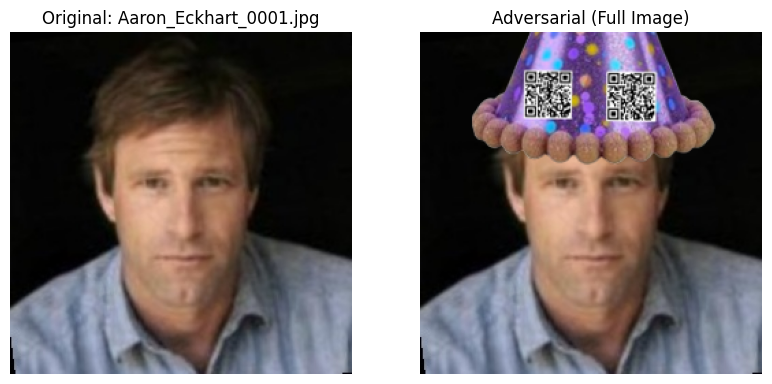

In [38]:
import matplotlib.pyplot as plt

test_idx = 2

person_folders = sorted([d for d in os.listdir(lfw_final_path) if os.path.isdir(os.path.join(lfw_final_path, d))])
test_person = person_folders[test_idx]
test_person_path = os.path.join(lfw_final_path, test_person)
test_img_name = sorted(os.listdir(test_person_path))[0]
test_img_path = os.path.join(test_person_path, test_img_name)


img_orig_bgr = cv2.imread(test_img_path)
img_orig_rgb = cv2.cvtColor(img_orig_bgr, cv2.COLOR_BGR2RGB)


faces = app.get(img_orig_bgr)

if len(faces) == 0:
    print(f"Error: Face detection failed for {test_img_name}.")
else:

    face = faces[0]
    kps = face.kps
    eye_center = ((kps[0][0] + kps[1][0]) / 2, (kps[0][1] + kps[1][1]) / 2)
    eye_dist = np.linalg.norm(kps[0] - kps[1])

    # Scale Hat
    hat_width = int(eye_dist * 4.0)
    h_h, h_w = hat_img.shape[:2]
    aspect_ratio = h_h / h_w
    hat_height = int(hat_width * aspect_ratio)
    resized_hat = cv2.resize(hat_img, (hat_width, hat_height), interpolation=cv2.INTER_AREA)

    dY = kps[1][1] - kps[0][1]
    dX = kps[1][0] - kps[0][0]
    angle = np.degrees(np.arctan2(dY, dX))
    M = cv2.getRotationMatrix2D((hat_width // 2, hat_height // 2), angle, 1)
    rotated_hat = cv2.warpAffine(resized_hat, M, (hat_width, hat_height),
                                flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_CONSTANT, borderValue=(0, 0, 0, 0))


    y_offset = int(eye_dist * 3)
    x1 = int(eye_center[0] - hat_width // 2)
    y1 = int(eye_center[1] - hat_height // 2 - y_offset)

    alpha_hat = rotated_hat[:, :, 3] / 255.0
    alpha_face = 1.0 - alpha_hat

    img_attacked_rgb = img_orig_rgb.copy()
    f_h, f_w = img_attacked_rgb.shape[:2]

    for c in range(0, 3):
        for y in range(0, hat_height):
            for x in range(0, hat_width):
                fi_y = y1 + y
                fi_x = x1 + x
                if 0 <= fi_y < f_h and 0 <= fi_x < f_w:
                    # In RGB now
                    img_attacked_rgb[fi_y, fi_x, c] = (alpha_hat[y, x] * rotated_hat[y, x, c] +
                                                      alpha_face[y, x] * img_attacked_rgb[fi_y, fi_x, c])
    img_attacked_bgr = cv2.cvtColor(img_attacked_rgb, cv2.COLOR_RGB2BGR)
    attacked_norm_bgr = face_align.norm_crop(img_attacked_bgr, landmark=face.kps)
    attacked_norm_rgb = cv2.cvtColor(attacked_norm_bgr, cv2.COLOR_BGR2RGB)

    # --- Plotting Results ---
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(img_orig_rgb)
    plt.title(f"Original: {test_img_name}")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(img_attacked_rgb)
    plt.title("Adversarial (Full Image)")
    plt.axis('off')

    plt.show()